##### Copyright 2023 The MediaPipe Authors. All Rights Reserved.

In [1]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Pose Landmarks Detection with MediaPipe Tasks

This notebook shows you how to use the MediaPipe Tasks Python API to detect pose landmarks from images.

This version has been adapted to run **locally** (no Google Colab required), using
`data/pose/images_man_standing.jpeg` from this repository as the input image.

## Preparation

This notebook needs the packages listed in `requirements.txt`: `mediapipe`, `opencv-python`,
`matplotlib` and `numpy`. If anything is missing, uncomment the `%pip install` line below and
re-run this cell.

In [2]:
# %pip install -q -r ../../requirements.txt
# %pip install -q mediapipe opencv-python matplotlib numpy

import importlib.util

missing = [m for m in ("mediapipe", "cv2", "matplotlib", "numpy") if importlib.util.find_spec(m) is None]
print("Missing packages:", missing if missing else "none (all installed)")

Missing packages: none (all installed)


## Project paths and model bundle

The notebook locates the repository root on its own, so you can open it either from `src/pose/`
or from the repository root. The `pose_landmarker.task` model bundle is downloaded once into
`models/` and reused afterwards. Check out the
[MediaPipe documentation](https://developers.google.com/mediapipe/solutions/vision/pose_landmarker#models)
for more information about this model bundle.

In [3]:
import urllib.request
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    """Return the first directory, walking up from `start`, that contains data/pose."""
    for path in (start, *start.parents):
        if (path / "data" / "pose").is_dir():
            return path
    raise FileNotFoundError(f"Could not locate the repository root (data/pose) starting from {start}")


ROOT = find_repo_root(Path.cwd().resolve())
IMAGE_PATH = ROOT / "data" / "pose" / "images_man_standing.jpeg"
MODEL_PATH = ROOT / "models" / "pose_landmarker.task"
MODEL_URL = (
    "https://storage.googleapis.com/mediapipe-models/pose_landmarker/"
    "pose_landmarker_heavy/float16/1/pose_landmarker_heavy.task"
)

assert IMAGE_PATH.is_file(), f"Input image not found: {IMAGE_PATH}"

if not MODEL_PATH.is_file():
    MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
    print("Downloading the pose_landmarker.task model bundle ...")
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)

print("ROOT       :", ROOT)
print("IMAGE_PATH :", IMAGE_PATH)
print("MODEL_PATH :", MODEL_PATH, f"({MODEL_PATH.stat().st_size / 1e6:.1f} MB)")

ROOT       : /Users/macbook/Documents/EduVisionSeat/EduVisionSeat
IMAGE_PATH : /Users/macbook/Documents/EduVisionSeat/EduVisionSeat/data/pose/images_man_standing.jpeg
MODEL_PATH : /Users/macbook/Documents/EduVisionSeat/EduVisionSeat/models/pose_landmarker.task (30.7 MB)


## Visualization utilities

In [4]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
from mediapipe import solutions
from mediapipe.framework.formats import landmark_pb2


def draw_landmarks_on_image(rgb_image, detection_result):
    """Draw the detected pose landmarks on an RGB image and return the annotated copy."""
    # mp.Image.create_from_file() may return a 4-channel (RGBA) image, drawing_utils takes 3 channels.
    annotated_image = np.copy(np.asarray(rgb_image)[:, :, :3])

    for pose_landmarks in detection_result.pose_landmarks:
        # Convert the landmark list to protobuf so it can be used with drawing_utils.
        pose_landmarks_proto = landmark_pb2.NormalizedLandmarkList()
        pose_landmarks_proto.landmark.extend([
            landmark_pb2.NormalizedLandmark(x=lm.x, y=lm.y, z=lm.z)
            for lm in pose_landmarks
        ])
        solutions.drawing_utils.draw_landmarks(
            image=annotated_image,
            landmark_list=pose_landmarks_proto,
            connections=solutions.pose.POSE_CONNECTIONS,
            landmark_drawing_spec=solutions.drawing_styles.get_default_pose_landmarks_style(),
            connection_drawing_spec=solutions.drawing_utils.DrawingSpec(color=(0, 255, 0), thickness=2),
        )

    return annotated_image


def show_image(rgb_image, title=None, width=8):
    """Display an RGB image inline (the local replacement for Colab's cv2_imshow)."""
    rgb_image = np.asarray(rgb_image)[:, :, :3]
    height = width * rgb_image.shape[0] / rgb_image.shape[1]
    plt.figure(figsize=(width, height))
    plt.imshow(rgb_image)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

## Input image

The input is `data/pose/images_man_standing.jpeg`. To try a different picture, just point
`IMAGE_PATH` somewhere else in the cell above (for example
`IMAGE_PATH = ROOT / "data" / "pose" / "another_image.jpg"`).

Image shape (H, W, C): (679, 452, 3)


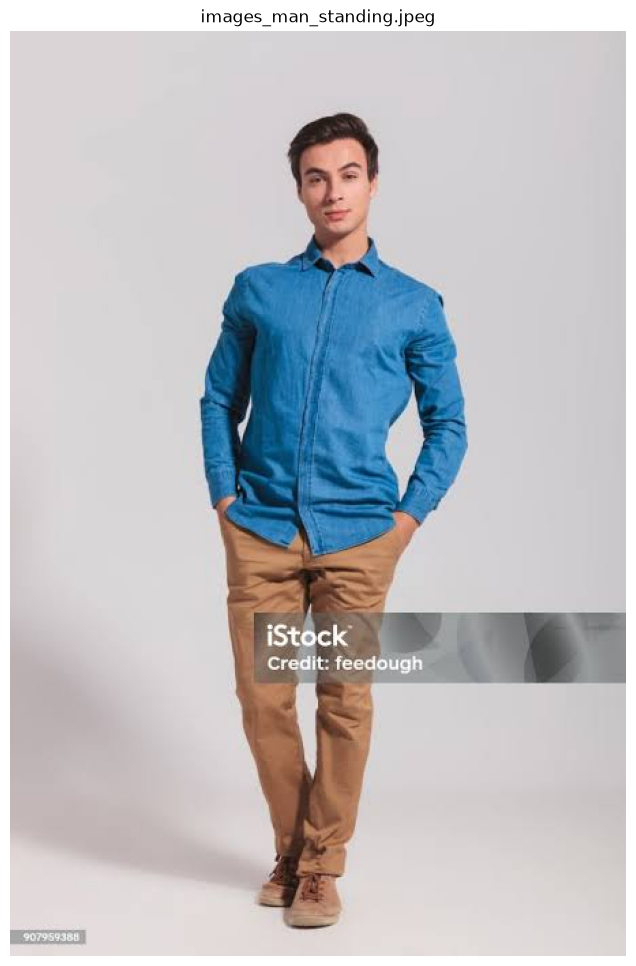

In [5]:
import cv2

bgr_image = cv2.imread(str(IMAGE_PATH))
assert bgr_image is not None, f"Failed to read the image: {IMAGE_PATH}"

print("Image shape (H, W, C):", bgr_image.shape)
show_image(cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB), title=IMAGE_PATH.name)

## Running inference and visualizing the results

The final step is to run pose landmark detection on the selected image. This involves creating the
PoseLandmarker object, loading the image, running detection, and finally displaying the image with
the visualizations. Check out the
[MediaPipe documentation](https://developers.google.com/mediapipe/solutions/vision/pose_landmarker/python)
to learn more about the configuration options that this solution supports.

I0000 00:00:1786955523.881351 3549578 gl_context.cc:369] GL version: 2.1 (2.1 INTEL-18.8.16), renderer: Intel(R) Iris(TM) Graphics 540
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1786955524.553651 3549715 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786955525.322268 3549717 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786955525.583666 3549716 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


Detected poses: 1


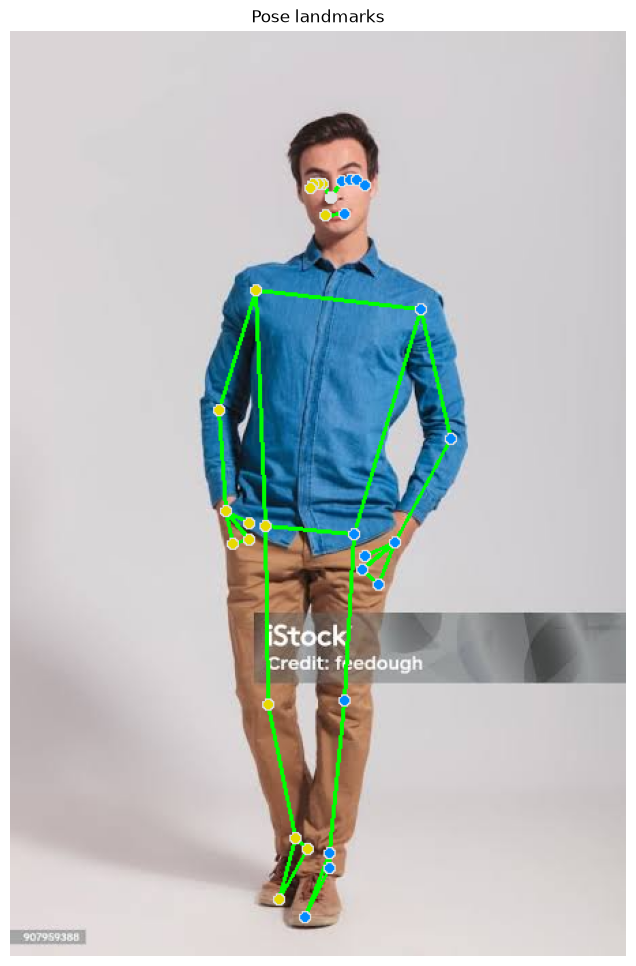

In [6]:
# STEP 1: Import the necessary modules.
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# STEP 2: Create a PoseLandmarker object.
base_options = python.BaseOptions(model_asset_path=str(MODEL_PATH))
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    output_segmentation_masks=True)
detector = vision.PoseLandmarker.create_from_options(options)

# STEP 3: Load the input image.
image = mp.Image.create_from_file(str(IMAGE_PATH))

# STEP 4: Detect pose landmarks from the input image.
detection_result = detector.detect(image)
print("Detected poses:", len(detection_result.pose_landmarks))

# STEP 5: Process the detection result. In this case, visualize it.
annotated_image = draw_landmarks_on_image(image.numpy_view(), detection_result)
show_image(annotated_image, title="Pose landmarks")

In [11]:
image = mp.Image.create_from_file(str(IMAGE_PATH))


print(type(image.numpy_view()))

print(detection_result)

<class 'numpy.ndarray'>
PoseLandmarkerResult(pose_landmarks=[[NormalizedLandmark(x=0.5207210779190063, y=0.18084093928337097, z=-0.8279223442077637, visibility=0.999944806098938, presence=0.9999459981918335), NormalizedLandmark(x=0.5380852818489075, y=0.1628722846508026, z=-0.7973536849021912, visibility=0.9998881816864014, presence=0.9999086856842041), NormalizedLandmark(x=0.5513370037078857, y=0.16172009706497192, z=-0.7981123924255371, visibility=0.9998835325241089, presence=0.9999202489852905), NormalizedLandmark(x=0.5625185966491699, y=0.16102761030197144, z=-0.7979925274848938, visibility=0.9999082088470459, presence=0.999901294708252), NormalizedLandmark(x=0.5086624622344971, y=0.1654110848903656, z=-0.7821597456932068, visibility=0.9999125003814697, presence=0.9998712539672852), NormalizedLandmark(x=0.5001945495605469, y=0.1655457317829132, z=-0.783016562461853, visibility=0.9999247789382935, presence=0.9998929500579834), NormalizedLandmark(x=0.49119654297828674, y=0.1655117869

Visualize the pose segmentation mask.

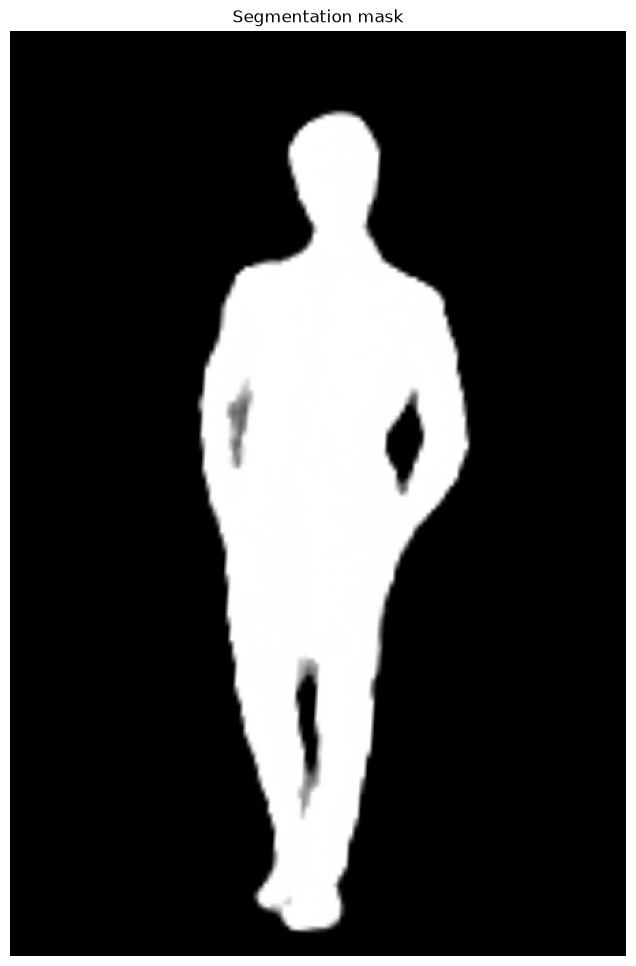

In [ ]:
segmentation_mask = np.squeeze(detection_result.segmentation_masks[0].numpy_view())

# Convert to a 3-channel uint8 image for visualization.
visualized_mask = (segmentation_mask * 255).astype(np.uint8)
visualized_mask = np.stack([visualized_mask] * 3, axis=-1)

show_image(visualized_mask, title="Segmentation mask")

The first few landmark coordinates (normalized to the image size).

In [9]:
POSE_LANDMARK_NAMES = [lm.name for lm in solutions.pose.PoseLandmark]

for idx, landmark in enumerate(detection_result.pose_landmarks[0][:8]):
    print(f"{idx:2d} {POSE_LANDMARK_NAMES[idx]:<18} "
          f"x={landmark.x:.3f} y={landmark.y:.3f} z={landmark.z:.3f} vis={landmark.visibility:.2f}")

print(f"... {len(detection_result.pose_landmarks[0])} landmarks in total")

 0 NOSE               x=0.521 y=0.181 z=-0.828 vis=1.00
 1 LEFT_EYE_INNER     x=0.538 y=0.163 z=-0.797 vis=1.00
 2 LEFT_EYE           x=0.551 y=0.162 z=-0.798 vis=1.00
 3 LEFT_EYE_OUTER     x=0.563 y=0.161 z=-0.798 vis=1.00
 4 RIGHT_EYE_INNER    x=0.509 y=0.165 z=-0.782 vis=1.00
 5 RIGHT_EYE          x=0.500 y=0.166 z=-0.783 vis=1.00
 6 RIGHT_EYE_OUTER    x=0.491 y=0.166 z=-0.784 vis=1.00
 7 LEFT_EAR           x=0.576 y=0.168 z=-0.572 vis=1.00
... 33 landmarks in total
